In [1]:
import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import numpy as np
import pandas as pd
import scipy.stats as st

from matplotlib import pyplot as plt

from src import StudentTSource

evaluated_dfs = [3, 13, 30]

# PDF derivative, PDF, CDF

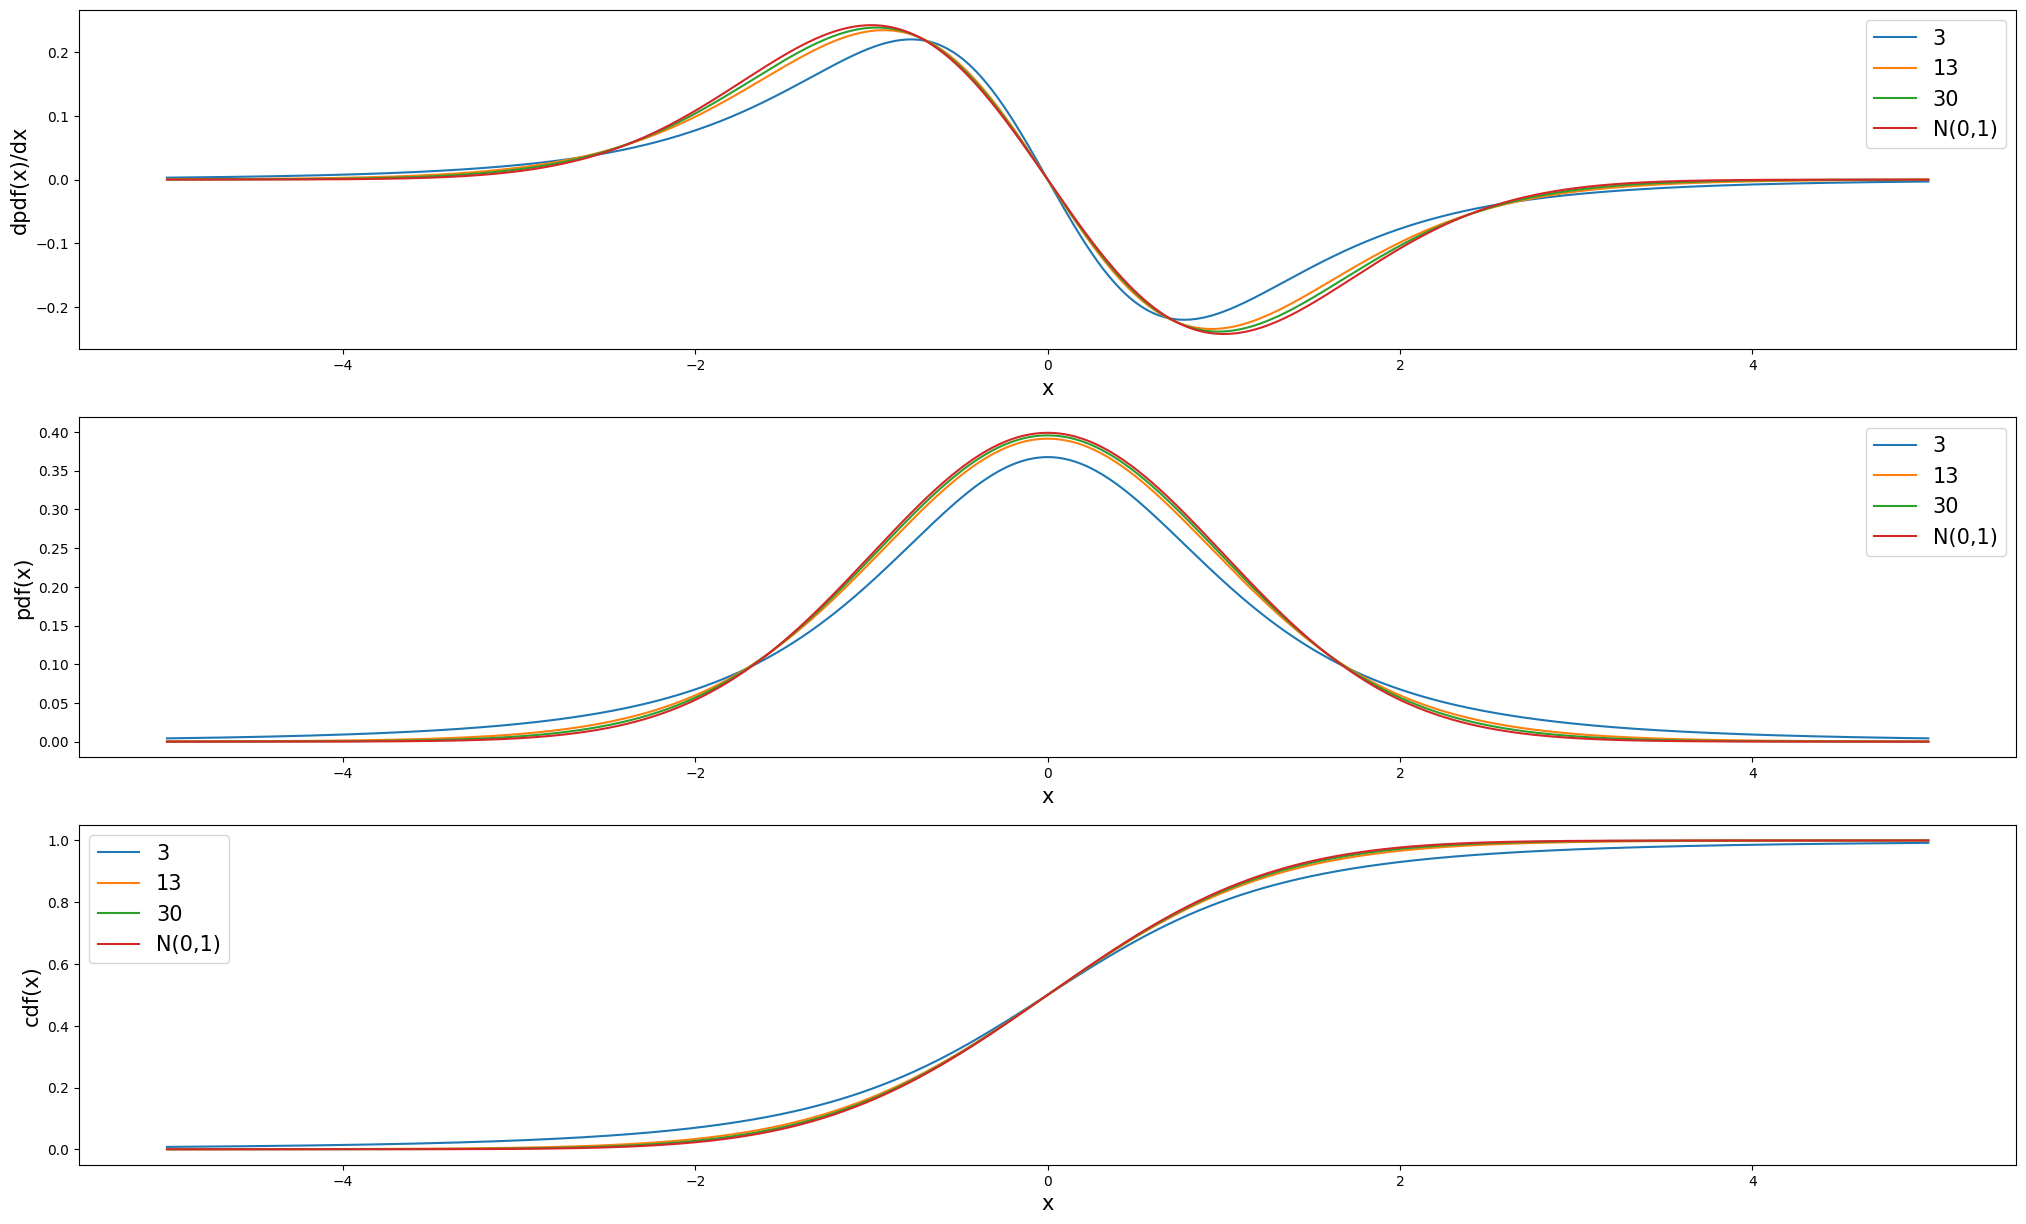

In [2]:
# x values for evaluation
evaluated_x = np.linspace(-5,5,1000)

# Instantiate sources
sources = {str(df): StudentTSource(
    mu=0,
    sigma=1,
    df=df
) for df in evaluated_dfs}

# Create plots
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=3, ncols=1,
    figsize=(25,15)
)

ax1.set_xlabel(
    'x',
    fontsize=15
)
ax2.set_xlabel(
    'x',
    fontsize=15
)
ax3.set_xlabel(
    'x',
    fontsize=15
)
ax1.set_ylabel(
    'dpdf(x)/dx',
    fontsize=15
)
ax2.set_ylabel(
    'pdf(x)',
    fontsize=15
)
ax3.set_ylabel(
    'cdf(x)',
    fontsize=15
)

# Plot t
for df, s in sources.items():
    pdf_derivative_fn = s.get_derivative()
    pdf_fn = s.get()
    cdf_fn = s.get_cumulative()

    ax1.plot(
        evaluated_x,
        [pdf_derivative_fn(x) for x in evaluated_x],
        label=df
    )

    ax2.plot(
        evaluated_x,
        pdf_fn(evaluated_x),
        label=df
    )

    ax3.plot(
        evaluated_x,
        cdf_fn(evaluated_x),
        label=df
    )

# Plot normal
normal_pdf_derivative_fn = lambda x: -x*st.norm.pdf(x)
ax1.plot(
    evaluated_x,
    [normal_pdf_derivative_fn(x) for x in evaluated_x],
    label='N(0,1)'
)

ax2.plot(
    evaluated_x,
    st.norm.pdf(evaluated_x),
    label='N(0,1)'
)

ax3.plot(
    evaluated_x,
    st.norm.cdf(evaluated_x),
    label='N(0,1)'
)

l1=ax1.legend(fontsize=15)
l2=ax2.legend(fontsize=15)
l3=ax3.legend(fontsize=15)



# Samples

/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_25694/3887212261.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l = ax.legend(fontsize=15)


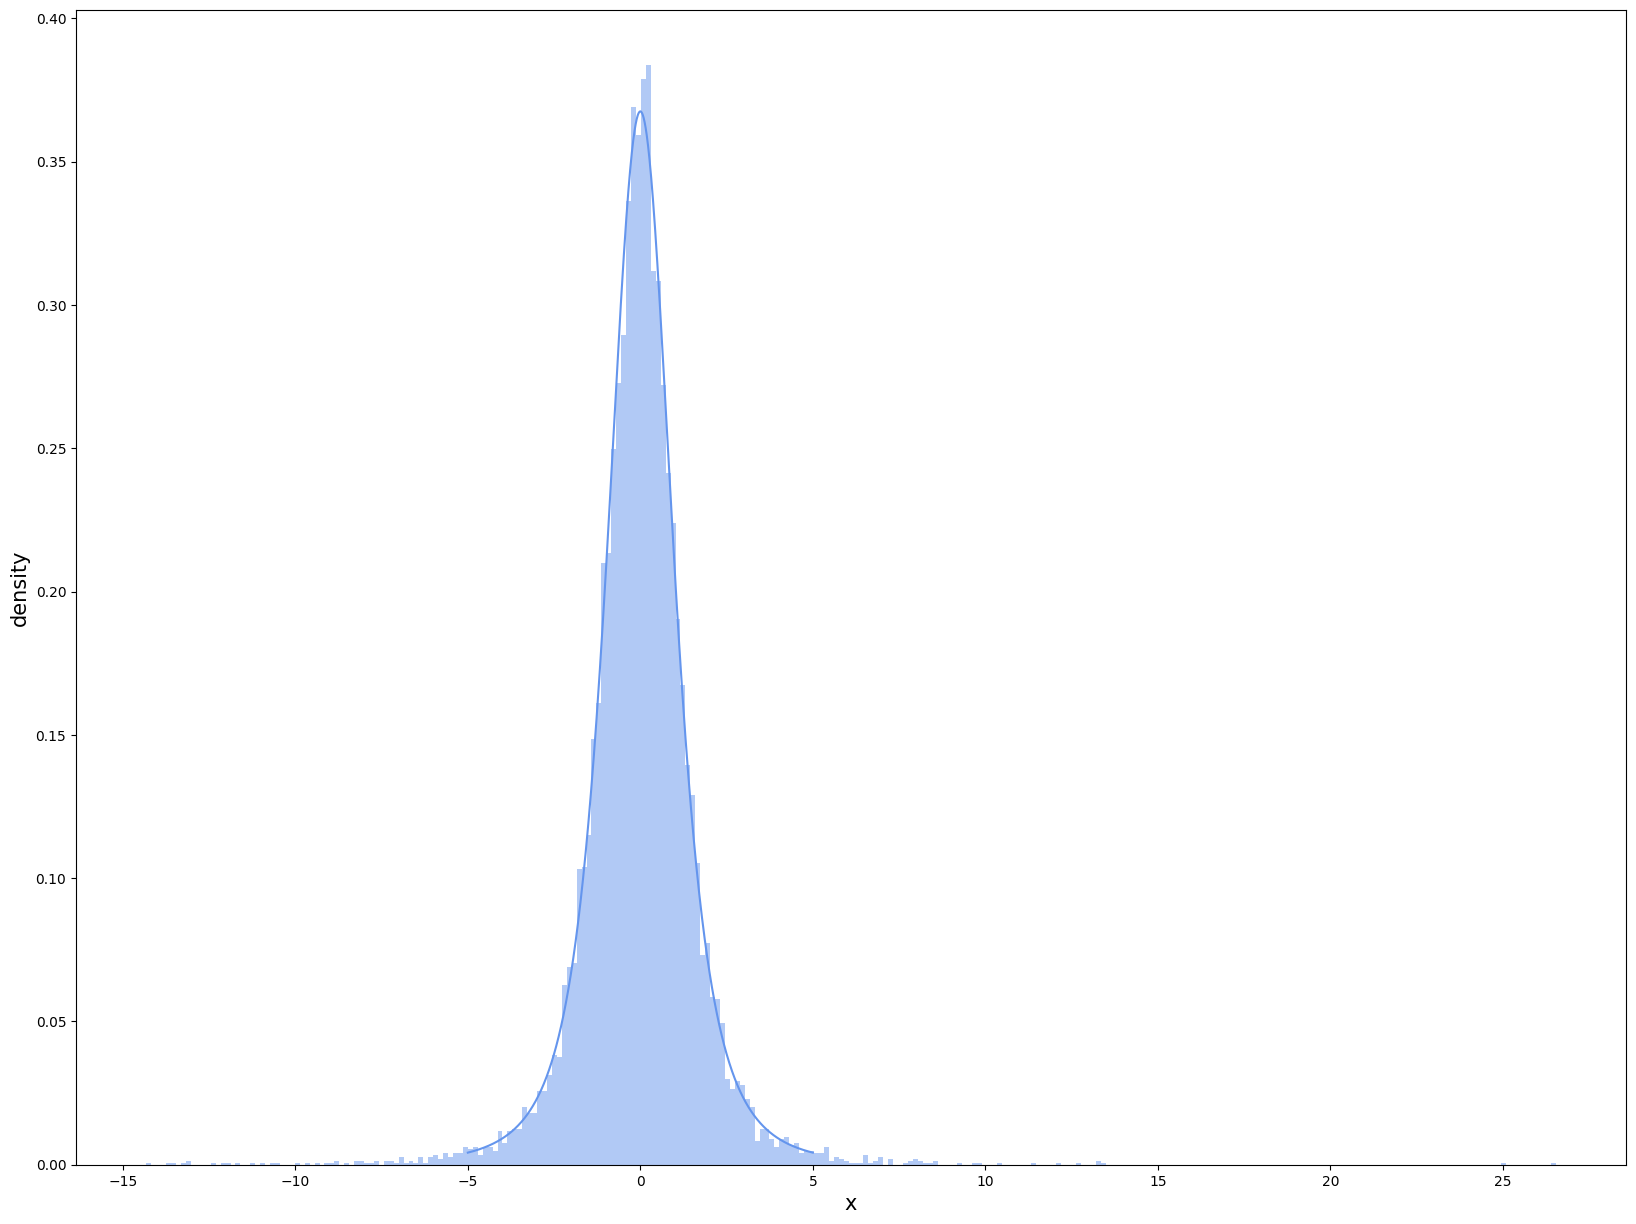

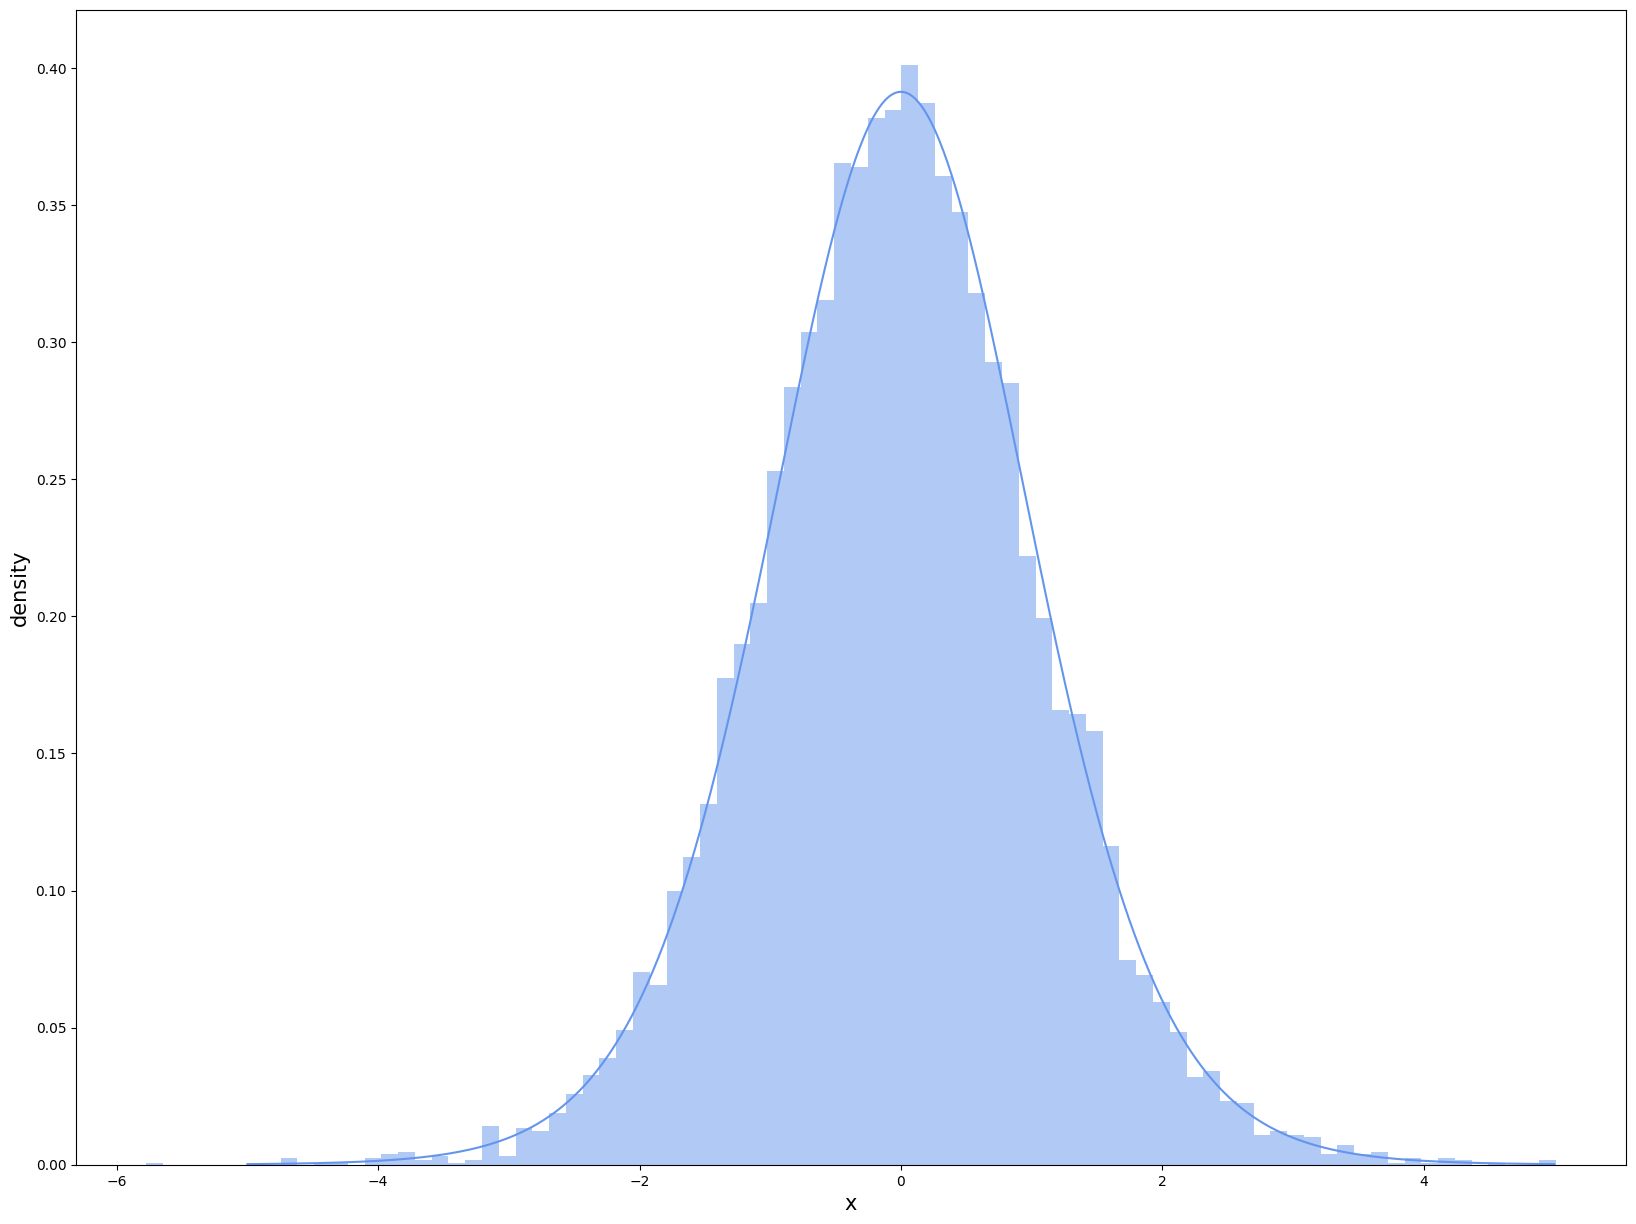

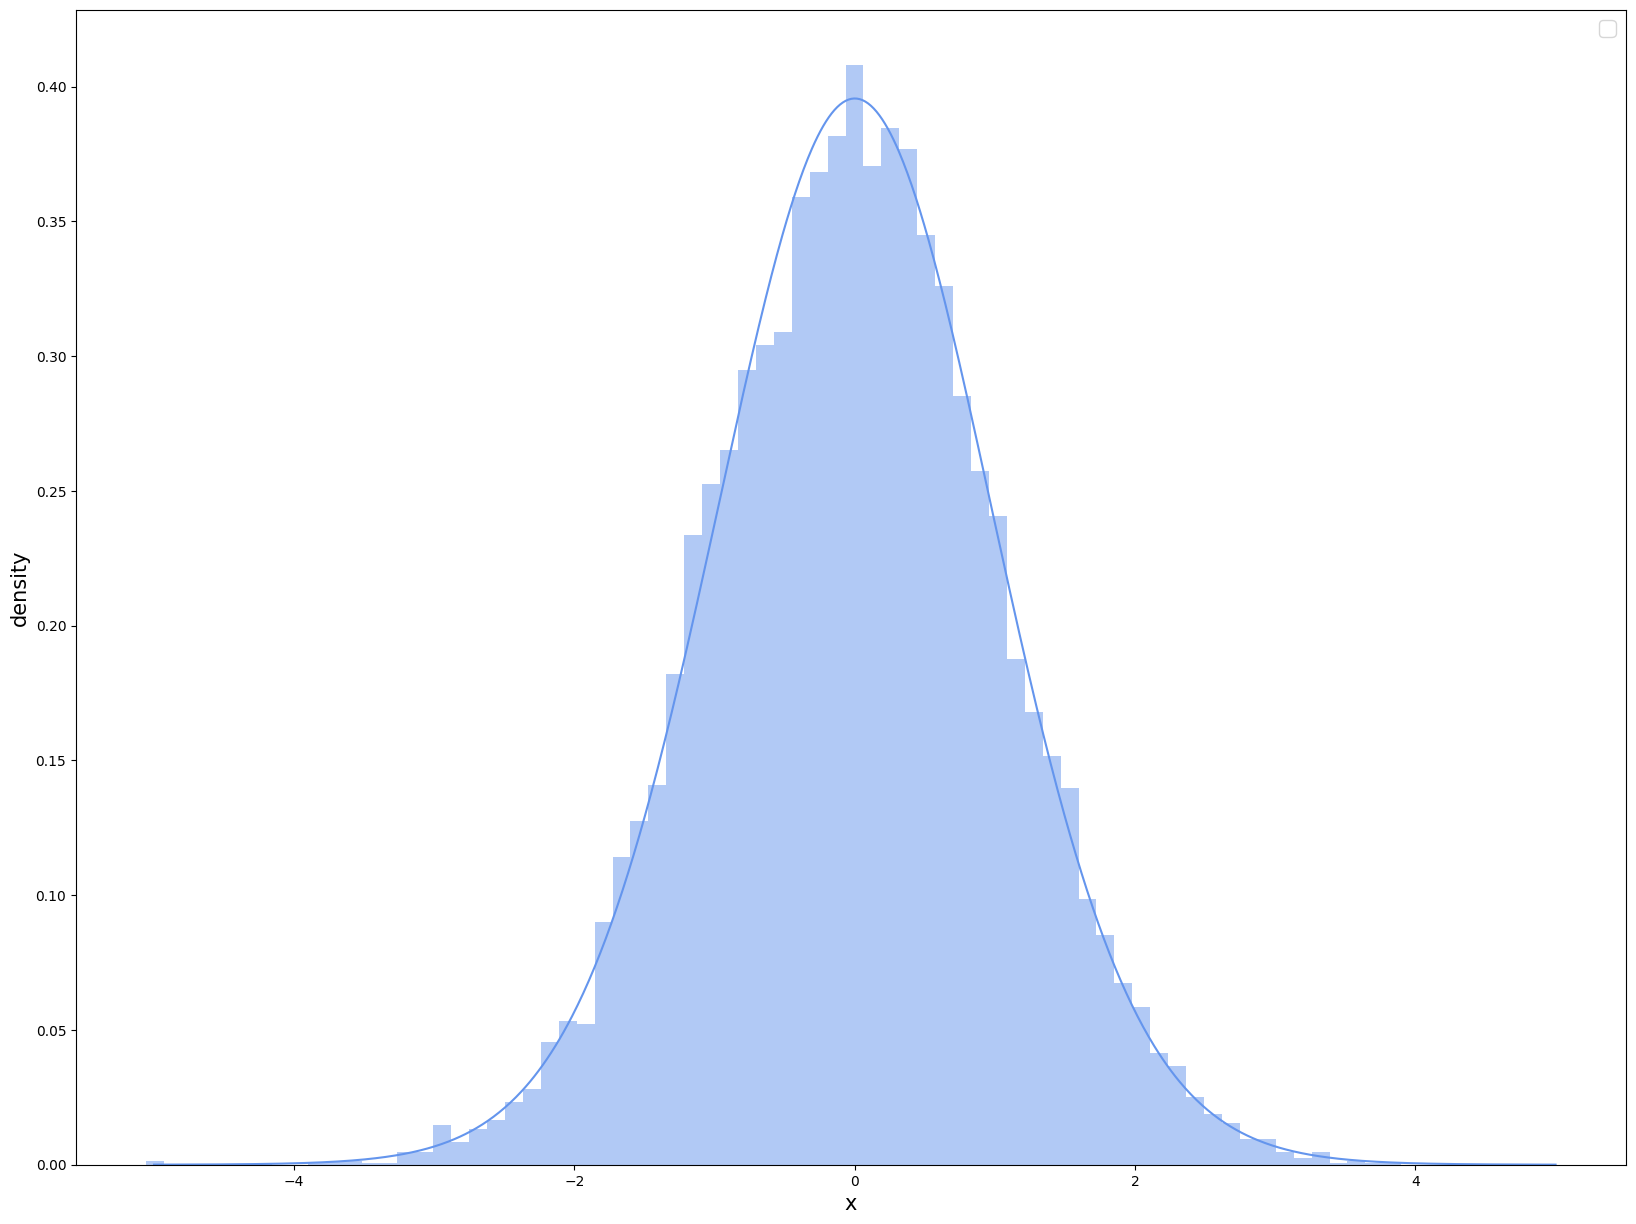

In [18]:
# Instantiate sources
sources = {str(df): StudentTSource(
    mu=0,
    sigma=1,
    df=df
) for df in evaluated_dfs}


# Plot t
for df, s in sources.items():
    fig, ax = plt.subplots(
        nrows=1, ncols=1,
        figsize=(20,15)
    )

    ax.set_xlabel(
        'x',
        fontsize=15
    )
    ax.set_ylabel(
        'density',
        fontsize=15
    )
    ax.hist(
        s.get_realization(nsources=1, nobs=10000)[0],
        bins='fd',
        alpha=0.5,
        density=True,
        color='cornflowerblue'
    )

    ax.plot(
        evaluated_x,
        s.get()(evaluated_x),
        color='cornflowerblue'
    )


l = ax.legend(fontsize=15)